## Imports

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math

## Ross exercise 13

#### setup data

In [3]:
data_13 = np.array([56, 101, 78, 67, 93, 87, 64, 72, 80, 69])
a = -5
b = 5

In [4]:
def bootstrap_probability_mean_difference(data, a=-5, b=5, B=10000):
    n = len(data)
    original_mean = np.mean(data)

    count = 0
    bootstrap_values = []

    for _ in range(B):
        bootstrap_sample = np.random.choice(data, size=n, replace=True)
        bootstrap_mean = np.mean(bootstrap_sample)

        value = bootstrap_mean - original_mean
        bootstrap_values.append(value)

        if a < value < b:
            count += 1

    p_hat = count / B

    return p_hat, np.array(bootstrap_values)

In [5]:
p_hat, bootstrap_values = bootstrap_probability_mean_difference(data_13,a=-5,b=5,B=10000)

print("Estimated probability:", p_hat)

Estimated probability: 0.7492


## Ross Exercise 15

In [6]:
data_15 = np.array([5, 4, 9, 6, 21, 17, 11, 20, 7, 10, 21, 15, 13, 16, 8])

In [7]:
def bootstrap_variance_of_sample_variance(data, B=10000):
    n = len(data)

    bootstrap_variances = []

    for _ in range(B):
        bootstrap_sample = np.random.choice(data, size=n, replace=True)
        sample_variance = np.var(bootstrap_sample, ddof=1)
        bootstrap_variances.append(sample_variance)

    bootstrap_variances = np.array(bootstrap_variances)

    estimated_var_S2 = np.var(bootstrap_variances, ddof=1)

    return estimated_var_S2, bootstrap_variances

In [8]:
estimated_var_S2, bootstrap_variances = bootstrap_variance_of_sample_variance(
    data_15,
    B=10000
)

print("Original sample variance:", np.var(data_15, ddof=1))
print("Bootstrap estimate of Var(S^2):", estimated_var_S2)

Original sample variance: 34.31428571428571
Bootstrap estimate of Var(S^2): 58.815147845745116


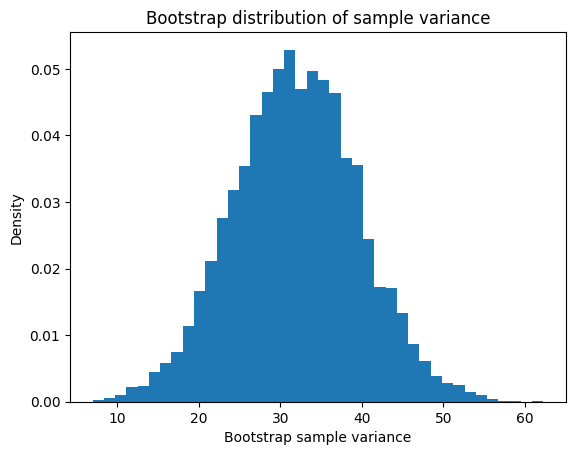

In [9]:
plt.hist(bootstrap_variances, bins=40, density=True)
plt.xlabel("Bootstrap sample variance")
plt.ylabel("Density")
plt.title("Bootstrap distribution of sample variance")
plt.show()

## Part 3

In [10]:
def pareto_rng(n, beta=1, shape=1.05):
    U = np.random.uniform(0, 1, n)
    return beta * U ** (-1 / shape)

In [11]:
def bootstrap_variance(data, estimator_function, B=100):
    n = len(data)

    bootstrap_estimates = []

    for _ in range(B):
        bootstrap_sample = np.random.choice(data, size=n, replace=True)
        estimate = estimator_function(bootstrap_sample)
        bootstrap_estimates.append(estimate)

    bootstrap_estimates = np.array(bootstrap_estimates)

    return np.var(bootstrap_estimates, ddof=1), bootstrap_estimates

In [12]:
def sample_median_and_bootstrap_variance(data, B=100):
    sample_median = np.median(data)
    bootstrap_var_median, bootstrap_medians = bootstrap_variance(
        data,
        np.median,
        B=B
    )

    return sample_median, bootstrap_var_median, bootstrap_medians

In [13]:
n = 200
beta = 1
shape = 1.05
B = 100

pareto_data = pareto_rng(n, beta=beta, shape=shape)

sample_mean = np.mean(pareto_data)
sample_median = np.median(pareto_data)

bootstrap_var_mean, bootstrap_means = bootstrap_variance(
    pareto_data,
    np.mean,
    B=B
)

bootstrap_var_median, bootstrap_medians = bootstrap_variance(
    pareto_data,
    np.median,
    B=B
)

print("Sample mean:", sample_mean)
print("Sample median:", sample_median)
print()
print("Bootstrap variance of sample mean:", bootstrap_var_mean)
print("Bootstrap variance of sample median:", bootstrap_var_median)

Sample mean: 8.793608559648415
Sample median: 1.8077917582613137

Bootstrap variance of sample mean: 19.88893527937976
Bootstrap variance of sample median: 0.010376157817651568


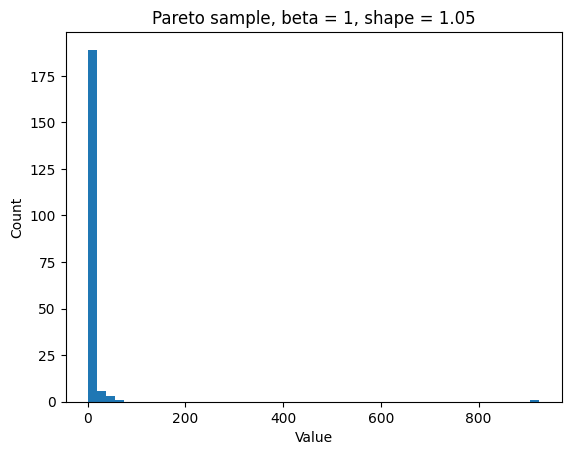

In [14]:
plt.hist(pareto_data, bins=50)
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Pareto sample, beta = 1, shape = 1.05")
plt.show()

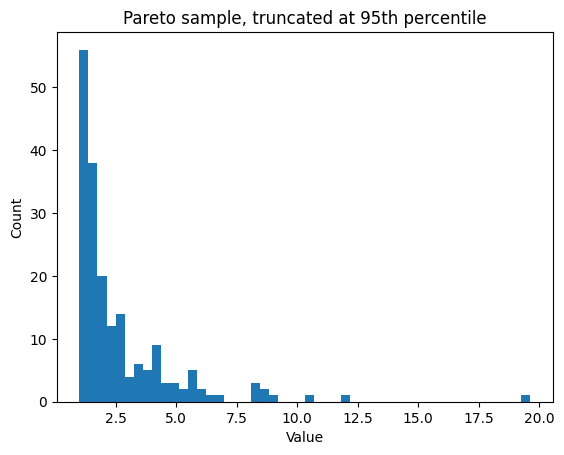

In [15]:
plt.hist(pareto_data, bins=50, range=(1, np.percentile(pareto_data, 95)))
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Pareto sample, truncated at 95th percentile")
plt.show()

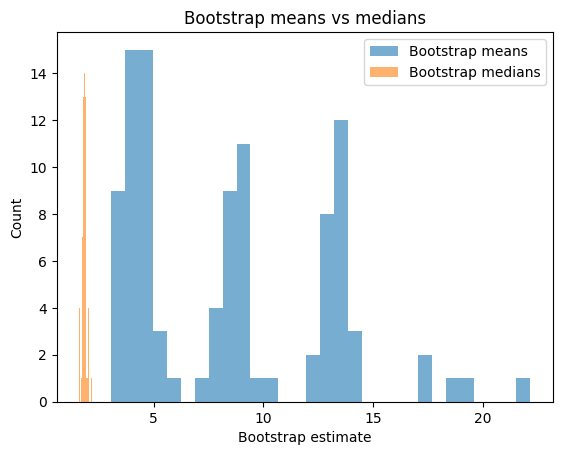

In [16]:
plt.hist(bootstrap_means, bins=30, alpha=0.6, label="Bootstrap means")
plt.hist(bootstrap_medians, bins=30, alpha=0.6, label="Bootstrap medians")
plt.xlabel("Bootstrap estimate")
plt.ylabel("Count")
plt.title("Bootstrap means vs medians")
plt.legend()
plt.show()